In [47]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [48]:
df = pd.read_csv("Bank_statements.csv")
df

,Unnamed: 0,DATA_SOURCE,FILE_NAME,BANK_ID,DT_REPORT,EXTRACTION_DATE,STATEMENT_TYPE,CATEGORY_TYPE,ORIGINAL_CATEGORY,CATEGORY_CODE,CURRENT_VALUE,PREVIOUS_VALUE,CATEGORY_TYPE_NUM,REPORT_DATE,YEAR,QUARTER
0,0,Raiffeisen Kosovo,rbko_is_31.12.2018.pdf,1,2018-12-31,2026-03-18,INCOME_STATEMENT,INCOME,Fitimi (humbja) para tatimit,14,26707.0,19602.0,1,2018-12-31,2018.0,4.0
1,1,Raiffeisen Kosovo,rbko_is_31.12.2018.pdf,1,2018-12-31,2026-03-18,INCOME_STATEMENT,INCOME,Të hyrat nga tarifat dhe komisionet,4,17569.0,13511.0,1,2018-12-31,2018.0,4.0
2,2,Raiffeisen Kosovo,rbko_is_31.12.2018.pdf,1,2018-12-31,2026-03-18,INCOME_STATEMENT,INCOME,Të hyrat nga interesi,1,43090.0,30651.0,1,2018-12-31,2018.0,4.0
3,3,Raiffeisen Kosovo,rbko_is_31.12.2018.pdf,1,2018-12-31,2026-03-18,INCOME_STATEMENT,INCOME,Të ardhurat tjera gjithëpërfshirëse,17,-345.0,-57.0,1,2018-12-31,2018.0,4.0
4,4,Raiffeisen Kosovo,rbko_is_31.12.2018.pdf,1,2018-12-31,2026-03-18,INCOME_STATEMENT,INCOME,Neto të hyrat nga tregtimi,7,-178.0,-244.0,1,2018-12-31,2018.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8968,8968,Ziraat Bank,zba_is_31.12.2025.pdf,7,2025-12-31,2026-03-18,INCOME_STATEMENT,INCOME,Të hyrat nga tarifat dhe komisionet,4,87.0,479.0,1,2025-12-31,2025.0,4.0
8969,8969,Ziraat Bank,zba_is_31.12.2025.pdf,7,2025-12-31,2026-03-18,INCOME_STATEMENT,INCOME,Shpenzimet e tarifave dhe komisioneve,5,98.0,353.0,1,2025-12-31,2025.0,4.0
8970,8970,Ziraat Bank,zba_is_31.12.2025.pdf,7,2025-12-31,2026-03-18,INCOME_STATEMENT,INCOME,Neto të hyrat nga tarifat dhe komisionet,6,11.0,126.0,1,2025-12-31,2025.0,4.0
8971,8971,Ziraat Bank,zba_is_31.12.2025.pdf,7,2025-12-31,2026-03-18,INCOME_STATEMENT,INCOME,Neto të hyrat tjera,80,18.0,150.0,1,2025-12-31,2025.0,4.0


In [49]:
df = df.drop(columns=["Unnamed: 0"])

In [50]:
TARGET_CODE = 16
TARGET_COL  = 'net_profit'

In [51]:
final_df = df[['BANK_ID', 'DATA_SOURCE', 'YEAR', 'QUARTER', 'CATEGORY_CODE', 'CURRENT_VALUE']].copy()

In [52]:
final_df

,BANK_ID,DATA_SOURCE,YEAR,QUARTER,CATEGORY_CODE,CURRENT_VALUE
0,1,Raiffeisen Kosovo,2018.0,4.0,14,26707.0
1,1,Raiffeisen Kosovo,2018.0,4.0,4,17569.0
2,1,Raiffeisen Kosovo,2018.0,4.0,1,43090.0
3,1,Raiffeisen Kosovo,2018.0,4.0,17,-345.0
4,1,Raiffeisen Kosovo,2018.0,4.0,7,-178.0
...,...,...,...,...,...,...
8968,7,Ziraat Bank,2025.0,4.0,4,87.0
8969,7,Ziraat Bank,2025.0,4.0,5,98.0
8970,7,Ziraat Bank,2025.0,4.0,6,11.0
8971,7,Ziraat Bank,2025.0,4.0,80,18.0


In [53]:
final_df["DATA_SOURCE"].value_counts()

DATA_SOURCE
Banka Ekonomike      1982
ProCredit Bank       1716
TEB Kosovo           1520
Ziraat Bank          1376
NLB Bank             1300
Raiffeisen Kosovo     962
PriBank               117
Name: count, dtype: int64

In [54]:
pivot = final_df.pivot_table(
    index=['BANK_ID', 'DATA_SOURCE', 'YEAR', 'QUARTER'],
    columns='CATEGORY_CODE',
    values='CURRENT_VALUE',
    aggfunc='first'
).reset_index()

pivot.columns.name = None

In [55]:
pivot

,BANK_ID,DATA_SOURCE,YEAR,QUARTER,1,2,3,4,5,6,...,36,37,38,40,41,42,43,44,45,80
0,1,Raiffeisen Kosovo,2018.0,4.0,43090.0,-2344.0,40746.0,17569.0,-6882.0,10687.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Raiffeisen Kosovo,2019.0,1.0,10557.0,-585.0,9972.0,3737.0,-1750.0,1987.0,...,0.0,791616.0,63000.0,0.0,64047.0,3398.0,-19.0,0.0,886114.0,NaN
2,1,Raiffeisen Kosovo,2019.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,10302.0,742438.0,63000.0,0.0,40046.0,17232.0,-97.0,120181.0,NaN,NaN
3,1,Raiffeisen Kosovo,2019.0,3.0,33060.0,-1926.0,31134.0,13633.0,-5952.0,7681.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,Raiffeisen Kosovo,2019.0,4.0,44620.0,-2653.0,41967.0,18174.0,-7875.0,10299.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,7,Ziraat Bank,2024.0,4.0,1568.0,648.0,920.0,60.0,62.0,3.0,...,1177.0,94700.0,25000.0,NaN,1738.0,284.0,NaN,23545.0,118246.0,6.0
263,7,Ziraat Bank,2025.0,1.0,8007.0,3489.0,4518.0,451.0,591.0,139.0,...,1030.0,121742.0,25000.0,0.0,951.0,2051.0,0.0,23900.0,145642.0,159.0
264,7,Ziraat Bank,2025.0,2.0,6164.0,2643.0,3521.0,329.0,348.0,19.0,...,1024.0,108640.0,25000.0,0.0,951.0,962.0,0.0,24989.0,133629.0,65.0
265,7,Ziraat Bank,2025.0,3.0,4200.0,1847.0,2353.0,202.0,206.0,4.0,...,1057.0,117432.0,25000.0,0.0,951.0,1236.0,0.0,24715.0,142147.0,37.0


In [56]:
pivot["DATA_SOURCE"].value_counts()

DATA_SOURCE
Banka Ekonomike      52
TEB Kosovo           49
ProCredit Bank       46
Ziraat Bank          42
NLB Bank             41
Raiffeisen Kosovo    29
PriBank               8
Name: count, dtype: int64

In [57]:
pivot['time_idx'] = pivot['YEAR'].astype(int) * 4 + pivot['QUARTER'].astype(int)
pivot

,BANK_ID,DATA_SOURCE,YEAR,QUARTER,1,2,3,4,5,6,...,37,38,40,41,42,43,44,45,80,time_idx
0,1,Raiffeisen Kosovo,2018.0,4.0,43090.0,-2344.0,40746.0,17569.0,-6882.0,10687.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8076
1,1,Raiffeisen Kosovo,2019.0,1.0,10557.0,-585.0,9972.0,3737.0,-1750.0,1987.0,...,791616.0,63000.0,0.0,64047.0,3398.0,-19.0,0.0,886114.0,NaN,8077
2,1,Raiffeisen Kosovo,2019.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,742438.0,63000.0,0.0,40046.0,17232.0,-97.0,120181.0,NaN,NaN,8078
3,1,Raiffeisen Kosovo,2019.0,3.0,33060.0,-1926.0,31134.0,13633.0,-5952.0,7681.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8079
4,1,Raiffeisen Kosovo,2019.0,4.0,44620.0,-2653.0,41967.0,18174.0,-7875.0,10299.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,7,Ziraat Bank,2024.0,4.0,1568.0,648.0,920.0,60.0,62.0,3.0,...,94700.0,25000.0,NaN,1738.0,284.0,NaN,23545.0,118246.0,6.0,8100
263,7,Ziraat Bank,2025.0,1.0,8007.0,3489.0,4518.0,451.0,591.0,139.0,...,121742.0,25000.0,0.0,951.0,2051.0,0.0,23900.0,145642.0,159.0,8101
264,7,Ziraat Bank,2025.0,2.0,6164.0,2643.0,3521.0,329.0,348.0,19.0,...,108640.0,25000.0,0.0,951.0,962.0,0.0,24989.0,133629.0,65.0,8102
265,7,Ziraat Bank,2025.0,3.0,4200.0,1847.0,2353.0,202.0,206.0,4.0,...,117432.0,25000.0,0.0,951.0,1236.0,0.0,24715.0,142147.0,37.0,8103


In [58]:
pivot = pivot.sort_values(['BANK_ID', 'time_idx']).reset_index(drop=True)
pivot

,BANK_ID,DATA_SOURCE,YEAR,QUARTER,1,2,3,4,5,6,...,37,38,40,41,42,43,44,45,80,time_idx
0,1,Raiffeisen Kosovo,2018.0,4.0,43090.0,-2344.0,40746.0,17569.0,-6882.0,10687.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8076
1,1,Raiffeisen Kosovo,2019.0,1.0,10557.0,-585.0,9972.0,3737.0,-1750.0,1987.0,...,791616.0,63000.0,0.0,64047.0,3398.0,-19.0,0.0,886114.0,NaN,8077
2,1,Raiffeisen Kosovo,2019.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,742438.0,63000.0,0.0,40046.0,17232.0,-97.0,120181.0,NaN,NaN,8078
3,1,Raiffeisen Kosovo,2019.0,3.0,33060.0,-1926.0,31134.0,13633.0,-5952.0,7681.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8079
4,1,Raiffeisen Kosovo,2019.0,4.0,44620.0,-2653.0,41967.0,18174.0,-7875.0,10299.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,7,Ziraat Bank,2024.0,4.0,1568.0,648.0,920.0,60.0,62.0,3.0,...,94700.0,25000.0,NaN,1738.0,284.0,NaN,23545.0,118246.0,6.0,8100
263,7,Ziraat Bank,2025.0,1.0,8007.0,3489.0,4518.0,451.0,591.0,139.0,...,121742.0,25000.0,0.0,951.0,2051.0,0.0,23900.0,145642.0,159.0,8101
264,7,Ziraat Bank,2025.0,2.0,6164.0,2643.0,3521.0,329.0,348.0,19.0,...,108640.0,25000.0,0.0,951.0,962.0,0.0,24989.0,133629.0,65.0,8102
265,7,Ziraat Bank,2025.0,3.0,4200.0,1847.0,2353.0,202.0,206.0,4.0,...,117432.0,25000.0,0.0,951.0,1236.0,0.0,24715.0,142147.0,37.0,8103


In [59]:
pivot.head()

,BANK_ID,DATA_SOURCE,YEAR,QUARTER,1,2,3,4,5,6,...,37,38,40,41,42,43,44,45,80,time_idx
0,1,Raiffeisen Kosovo,2018.0,4.0,43090.0,-2344.0,40746.0,17569.0,-6882.0,10687.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8076
1,1,Raiffeisen Kosovo,2019.0,1.0,10557.0,-585.0,9972.0,3737.0,-1750.0,1987.0,...,791616.0,63000.0,0.0,64047.0,3398.0,-19.0,0.0,886114.0,NaN,8077
2,1,Raiffeisen Kosovo,2019.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,742438.0,63000.0,0.0,40046.0,17232.0,-97.0,120181.0,NaN,NaN,8078
3,1,Raiffeisen Kosovo,2019.0,3.0,33060.0,-1926.0,31134.0,13633.0,-5952.0,7681.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8079
4,1,Raiffeisen Kosovo,2019.0,4.0,44620.0,-2653.0,41967.0,18174.0,-7875.0,10299.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8080


In [60]:
pivot['16_lag1'] = pivot.groupby('BANK_ID')[16].shift(1)
pivot['16_lag2'] = pivot.groupby('BANK_ID')[16].shift(2)
pivot['16_lag4'] = pivot.groupby('BANK_ID')[16].shift(4)

pivot['16_roll4_mean'] = (
    pivot.groupby('BANK_ID')[16]
    .transform(lambda x: x.shift(1).rolling(4, min_periods=2).mean())
)

pivot

,BANK_ID,DATA_SOURCE,YEAR,QUARTER,1,2,3,4,5,6,...,42,43,44,45,80,time_idx,16_lag1,16_lag2,16_lag4,16_roll4_mean
0,1,Raiffeisen Kosovo,2018.0,4.0,43090.0,-2344.0,40746.0,17569.0,-6882.0,10687.0,...,NaN,NaN,NaN,NaN,NaN,8076,NaN,NaN,NaN,NaN
1,1,Raiffeisen Kosovo,2019.0,1.0,10557.0,-585.0,9972.0,3737.0,-1750.0,1987.0,...,3398.0,-19.0,0.0,886114.0,NaN,8077,23927.0,NaN,NaN,NaN
2,1,Raiffeisen Kosovo,2019.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,17232.0,-97.0,120181.0,NaN,NaN,8078,3398.0,23927.0,NaN,13662.500000
3,1,Raiffeisen Kosovo,2019.0,3.0,33060.0,-1926.0,31134.0,13633.0,-5952.0,7681.0,...,NaN,NaN,NaN,NaN,NaN,8079,NaN,3398.0,NaN,13662.500000
4,1,Raiffeisen Kosovo,2019.0,4.0,44620.0,-2653.0,41967.0,18174.0,-7875.0,10299.0,...,NaN,NaN,NaN,NaN,NaN,8080,12885.0,NaN,23927.0,13403.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,7,Ziraat Bank,2024.0,4.0,1568.0,648.0,920.0,60.0,62.0,3.0,...,284.0,NaN,23545.0,118246.0,6.0,8100,NaN,NaN,2416.0,NaN
263,7,Ziraat Bank,2025.0,1.0,8007.0,3489.0,4518.0,451.0,591.0,139.0,...,2051.0,0.0,23900.0,145642.0,159.0,8101,284.0,NaN,NaN,NaN
264,7,Ziraat Bank,2025.0,2.0,6164.0,2643.0,3521.0,329.0,348.0,19.0,...,962.0,0.0,24989.0,133629.0,65.0,8102,2051.0,284.0,NaN,1167.500000
265,7,Ziraat Bank,2025.0,3.0,4200.0,1847.0,2353.0,202.0,206.0,4.0,...,1236.0,0.0,24715.0,142147.0,37.0,8103,962.0,2051.0,NaN,1099.000000


In [61]:
for col in [1, 3, 6, 10, 14]:
    pivot[f'{col}_lag1'] = pivot.groupby('BANK_ID')[col].shift(1)

pivot['next_net_profit'] = pivot.groupby('BANK_ID')[16].shift(-1)

pivot['quarter_sin'] = np.sin(2 * np.pi * pivot['QUARTER'] / 4)
pivot['quarter_cos'] = np.cos(2 * np.pi * pivot['QUARTER'] / 4)

print(pivot[['BANK_ID', 'YEAR', 'QUARTER', 16, '16_lag1', 'next_net_profit']].head(10))

   BANK_ID    YEAR  QUARTER       16  16_lag1  next_net_profit
0        1  2018.0      4.0  23927.0      NaN           3398.0
1        1  2019.0      1.0   3398.0  23927.0              NaN
2        1  2019.0      2.0      NaN   3398.0          12885.0
3        1  2019.0      3.0  12885.0      NaN          17203.0
4        1  2019.0      4.0  17203.0  12885.0           2724.0
5        1  2020.0      1.0   2724.0  17203.0           6601.0
6        1  2020.0      2.0   6601.0   2724.0          11165.0
7        1  2020.0      3.0  11165.0   6601.0          16652.0
8        1  2020.0      4.0  16652.0  11165.0           6267.0
9        1  2021.0      1.0   6267.0  16652.0          12974.0


In [62]:
pivot['16_qoq_growth'] = pivot.groupby('BANK_ID')[16].pct_change(1)

pivot['profit_margin_lag1'] = (
    pivot.groupby('BANK_ID')[16].shift(1) / 
    pivot.groupby('BANK_ID')[10].shift(1)
)

pivot['provision_burden_lag1'] = (
    pivot.groupby('BANK_ID')[11].shift(1) / 
    pivot.groupby('BANK_ID')[10].shift(1)
)

pivot['year_feature'] = pivot['YEAR'].astype(int)

pivot['bank_quarters'] = pivot.groupby('BANK_ID').cumcount() + 1

In [63]:
EXCLUDE_COLS = [
    'DATA_SOURCE', 'BANK_ID', 'YEAR', 'QUARTER', 'time_idx',
    'next_net_profit',
    19,
    17,
    42
]

FEATURE_COLS = [
    c for c in pivot.columns
    if c not in EXCLUDE_COLS
    and pd.api.types.is_numeric_dtype(pivot[c])
]

df_model = pivot[pivot['next_net_profit'].notna()].sort_values(['time_idx', 'BANK_ID']).reset_index(drop=True)

X = df_model[FEATURE_COLS].fillna(0)
y = df_model['next_net_profit']

print(f'Features      : {len(FEATURE_COLS)}')
print(f'Training rows : {len(X)}')
print(FEATURE_COLS)

Features      : 56
Training rows : 249
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 40, 41, 43, 44, 45, 80, '16_lag1', '16_lag2', '16_lag4', '16_roll4_mean', '1_lag1', '3_lag1', '6_lag1', '10_lag1', '14_lag1', 'quarter_sin', 'quarter_cos', '16_qoq_growth', 'profit_margin_lag1', 'provision_burden_lag1', 'year_feature', 'bank_quarters']


In [64]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

tscv = TimeSeriesSplit(n_splits=5)

X = X.replace([np.inf, -np.inf], np.nan)

model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

maes, rmses, r2s = [], [], []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict(X_val)

    mae  = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2   = r2_score(y_val, preds)

    maes.append(mae); rmses.append(rmse); r2s.append(r2)
    print(f'Fold {fold} | MAE={mae:>10,.0f}  RMSE={rmse:>10,.0f}  R²={r2:.3f}')

Fold 1 | MAE=     2,123  RMSE=     3,124  R²=0.716
Fold 2 | MAE=     2,434  RMSE=     3,476  R²=0.679
Fold 3 | MAE=     2,047  RMSE=     2,745  R²=0.870
Fold 4 | MAE=     3,603  RMSE=     5,393  R²=0.715
Fold 5 | MAE=     3,655  RMSE=     5,582  R²=0.782


In [65]:
results = []

for bank_id, grp in pivot.groupby('BANK_ID'):
    latest = grp.sort_values('time_idx').iloc[-1]
    
    X_pred = pd.DataFrame([latest[FEATURE_COLS].fillna(0)])
    prediction = float(model.predict(X_pred)[0])
    
    last_quarter = int(latest['QUARTER'])
    last_year = int(latest['YEAR'])
    
    if last_quarter == 4:
        next_q, next_y = 1, last_year + 1
    else:
        next_q, next_y = last_quarter + 1, last_year
    
    results.append({
        'Bank'                    : latest['DATA_SOURCE'],
        'Last Period'             : f"Q{last_quarter} {last_year}",
        'Last Net Profit (€)'     : latest[16],
        'Forecast Period'         : f"Q{next_q} {next_y}",
        'Predicted Net Profit (€)': round(prediction, 2),
    })

predictions = pd.DataFrame(results)

predictions

,Bank,Last Period,Last Net Profit (€),Forecast Period,Predicted Net Profit (€)
0,Raiffeisen Kosovo,Q4 2025,31322.0,Q1 2026,14107.18
1,TEB Kosovo,Q4 2025,29221.0,Q1 2026,8090.47
2,NLB Bank,Q3 2025,30150.0,Q4 2025,19952.69
3,ProCredit Bank,Q4 2025,26791.0,Q1 2026,9067.42
4,Banka Ekonomike,Q4 2025,12173.0,Q1 2026,8691.43
5,PriBank,Q4 2025,-580.0,Q1 2026,556.31
6,Ziraat Bank,Q4 2025,631.0,Q1 2026,6.33


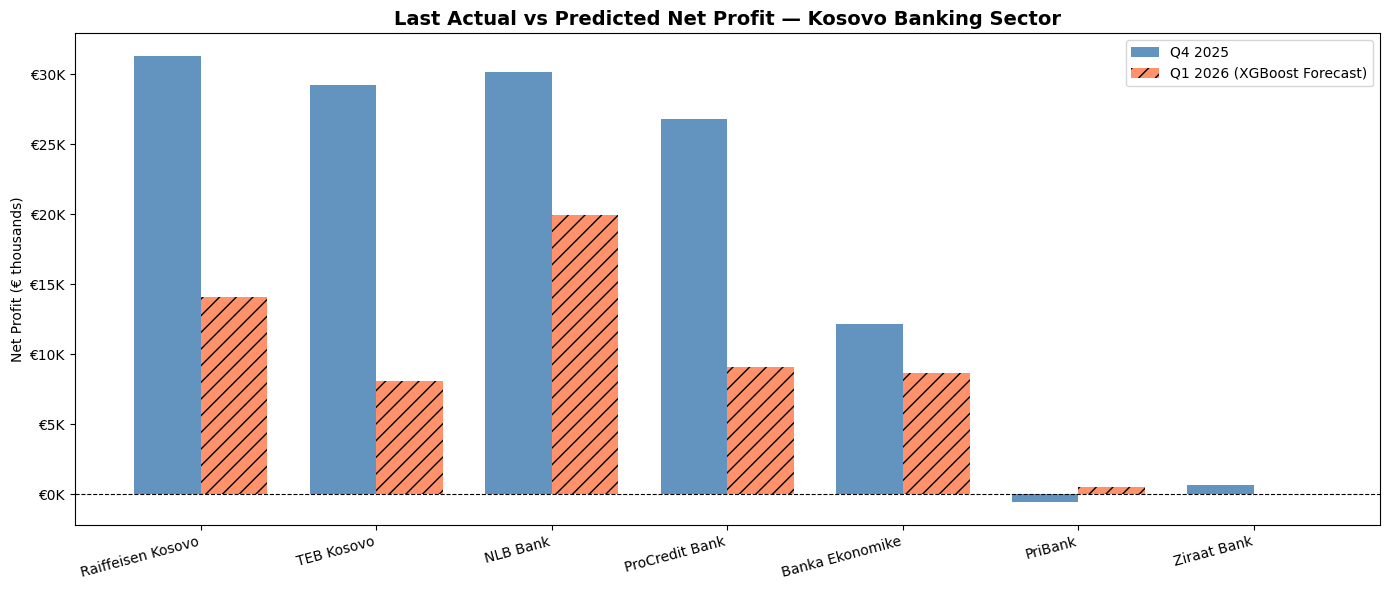

In [66]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(14, 6))

banks = predictions['Bank']
x = np.arange(len(banks))
width = 0.38

bars1 = ax.bar(x - width/2, predictions['Last Net Profit (€)'] / 1_000, 
               width, label='Q4 2025', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, predictions['Predicted Net Profit (€)'] / 1_000, 
               width, label='Q1 2026 (XGBoost Forecast)', color='coral', alpha=0.85, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(banks, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Net Profit (€ thousands)')
ax.set_title('Last Actual vs Predicted Net Profit — Kosovo Banking Sector', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'€{v:,.0f}K'))
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [67]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X.columns = X.columns.astype(str)

tscv = TimeSeriesSplit(n_splits=5)

model_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)

maes, rmses, r2s = [], [], []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model_rf.fit(X_tr, y_tr)
    preds = model_rf.predict(X_val)

    mae  = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2   = r2_score(y_val, preds)

    maes.append(mae); rmses.append(rmse); r2s.append(r2)
    print(f'Fold {fold} | MAE={mae:>10,.0f}  RMSE={rmse:>10,.0f}  R²={r2:.3f}')

Fold 1 | MAE=     2,539  RMSE=     3,697  R²=0.603
Fold 2 | MAE=     2,497  RMSE=     3,696  R²=0.637
Fold 3 | MAE=     2,495  RMSE=     3,327  R²=0.808
Fold 4 | MAE=     3,473  RMSE=     5,275  R²=0.728
Fold 5 | MAE=     3,387  RMSE=     5,607  R²=0.780


In [68]:
results = []

for bank_id, grp in pivot.groupby('BANK_ID'):
    latest = grp.sort_values('time_idx').iloc[-1]
    
    X_pred = pd.DataFrame([latest[FEATURE_COLS].fillna(0).replace([np.inf, -np.inf], 0)])
    X_pred.columns = X_pred.columns.astype(str)
    prediction = float(model_rf.predict(X_pred)[0])
    
    last_quarter = int(latest['QUARTER'])
    last_year = int(latest['YEAR'])
    
    if last_quarter == 4:
        next_q, next_y = 1, last_year + 1
    else:
        next_q, next_y = last_quarter + 1, last_year
    
    results.append({
        'Bank'                    : latest['DATA_SOURCE'],
        'Last Period'             : f"Q{last_quarter} {last_year}",
        'Last Net Profit (€)'     : latest[16],
        'Forecast Period'         : f"Q{next_q} {next_y}",
        'Predicted Net Profit (€)': round(prediction, 2),
    })

predictions_rf = pd.DataFrame(results)
predictions_rf

,Bank,Last Period,Last Net Profit (€),Forecast Period,Predicted Net Profit (€)
0,Raiffeisen Kosovo,Q4 2025,31322.0,Q1 2026,12346.19
1,TEB Kosovo,Q4 2025,29221.0,Q1 2026,9264.68
2,NLB Bank,Q3 2025,30150.0,Q4 2025,19921.53
3,ProCredit Bank,Q4 2025,26791.0,Q1 2026,9256.45
4,Banka Ekonomike,Q4 2025,12173.0,Q1 2026,6926.83
5,PriBank,Q4 2025,-580.0,Q1 2026,865.92
6,Ziraat Bank,Q4 2025,631.0,Q1 2026,1042.25


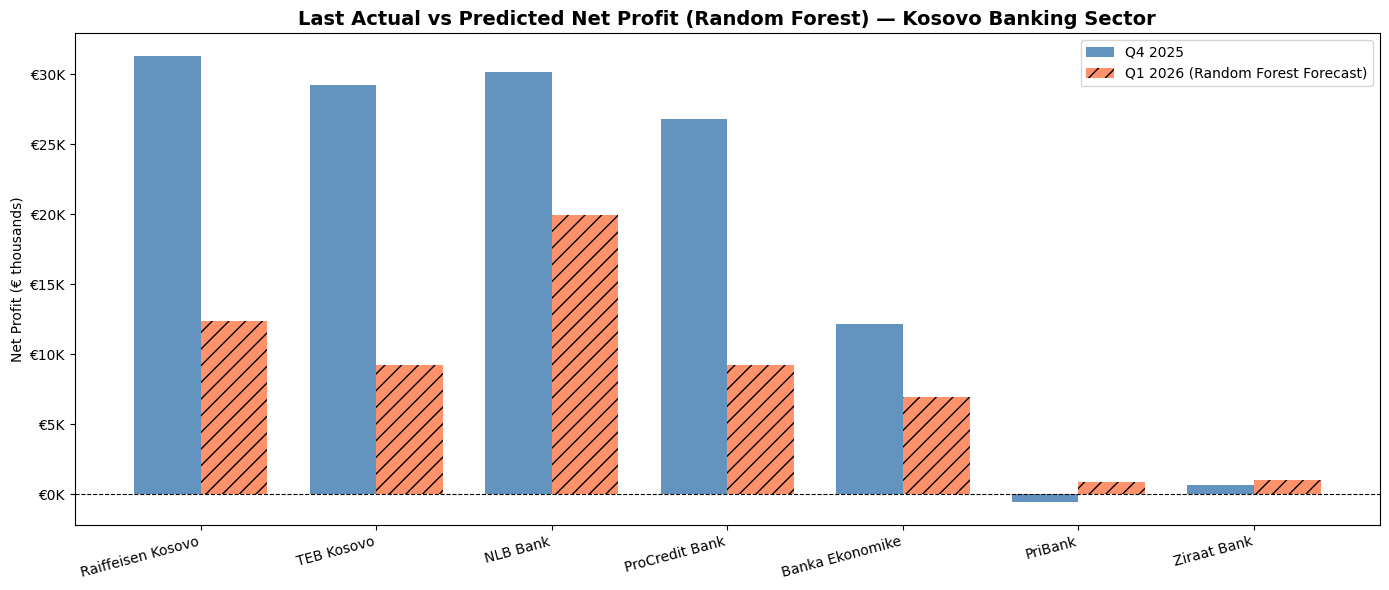

In [69]:
fig, ax = plt.subplots(figsize=(14, 6))

banks = predictions_rf['Bank']
x = np.arange(len(banks))
width = 0.38

ax.bar(x - width/2, predictions_rf['Last Net Profit (€)'] / 1_000,
       width, label='Q4 2025', color='steelblue', alpha=0.85)
ax.bar(x + width/2, predictions_rf['Predicted Net Profit (€)'] / 1_000,
       width, label='Q1 2026 (Random Forest Forecast)', color='coral', alpha=0.85, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(banks, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Net Profit (€ thousands)')
ax.set_title('Last Actual vs Predicted Net Profit (Random Forest) — Kosovo Banking Sector', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'€{v:,.0f}K'))
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [70]:
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tscv = TimeSeriesSplit(n_splits=5)

model_lgb = lgb.LGBMRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

maes, rmses, r2s = [], [], []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model_lgb.fit(X_tr, y_tr)
    preds = model_lgb.predict(X_val)

    mae  = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2   = r2_score(y_val, preds)

    maes.append(mae); rmses.append(rmse); r2s.append(r2)
    print(f'Fold {fold} | MAE={mae:>10,.0f}  RMSE={rmse:>10,.0f}  R²={r2:.3f}')

Fold 1 | MAE=     2,425  RMSE=     3,788  R²=0.583
Fold 2 | MAE=     2,592  RMSE=     3,590  R²=0.658
Fold 3 | MAE=     2,448  RMSE=     3,195  R²=0.823
Fold 4 | MAE=     3,442  RMSE=     5,107  R²=0.745
Fold 5 | MAE=     3,249  RMSE=     5,072  R²=0.820


In [71]:
results = []

for bank_id, grp in pivot.groupby('BANK_ID'):
    latest = grp.sort_values('time_idx').iloc[-1]
    
    X_pred = pd.DataFrame([latest[FEATURE_COLS].fillna(0).replace([np.inf, -np.inf], 0)])
    X_pred.columns = X_pred.columns.astype(str)
    prediction = float(model_lgb.predict(X_pred)[0])
    
    last_quarter = int(latest['QUARTER'])
    last_year = int(latest['YEAR'])
    
    if last_quarter == 4:
        next_q, next_y = 1, last_year + 1
    else:
        next_q, next_y = last_quarter + 1, last_year
    
    results.append({
        'Bank'                    : latest['DATA_SOURCE'],
        'Last Period'             : f"Q{last_quarter} {last_year}",
        'Last Net Profit (€)'     : latest[16],
        'Forecast Period'         : f"Q{next_q} {next_y}",
        'Predicted Net Profit (€)': round(prediction, 2),
    })

predictions_lgb = pd.DataFrame(results)
predictions_lgb

,Bank,Last Period,Last Net Profit (€),Forecast Period,Predicted Net Profit (€)
0,Raiffeisen Kosovo,Q4 2025,31322.0,Q1 2026,14243.36
1,TEB Kosovo,Q4 2025,29221.0,Q1 2026,7453.87
2,NLB Bank,Q3 2025,30150.0,Q4 2025,21616.57
3,ProCredit Bank,Q4 2025,26791.0,Q1 2026,6800.70
4,Banka Ekonomike,Q4 2025,12173.0,Q1 2026,8282.81
5,PriBank,Q4 2025,-580.0,Q1 2026,933.26
6,Ziraat Bank,Q4 2025,631.0,Q1 2026,138.13


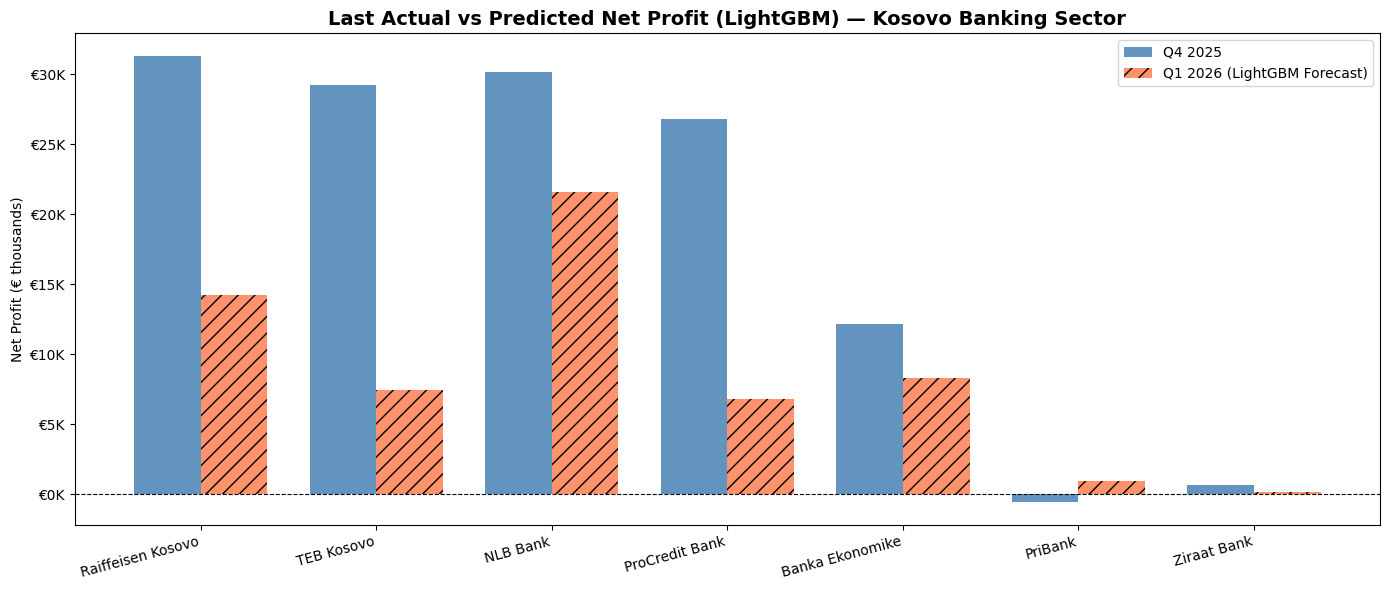

In [72]:
fig, ax = plt.subplots(figsize=(14, 6))

banks = predictions_lgb['Bank']
x = np.arange(len(banks))
width = 0.38

ax.bar(x - width/2, predictions_lgb['Last Net Profit (€)'] / 1_000,
       width, label='Q4 2025', color='steelblue', alpha=0.85)
ax.bar(x + width/2, predictions_lgb['Predicted Net Profit (€)'] / 1_000,
       width, label='Q1 2026 (LightGBM Forecast)', color='coral', alpha=0.85, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(banks, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Net Profit (€ thousands)')
ax.set_title('Last Actual vs Predicted Net Profit (LightGBM) — Kosovo Banking Sector', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'€{v:,.0f}K'))
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

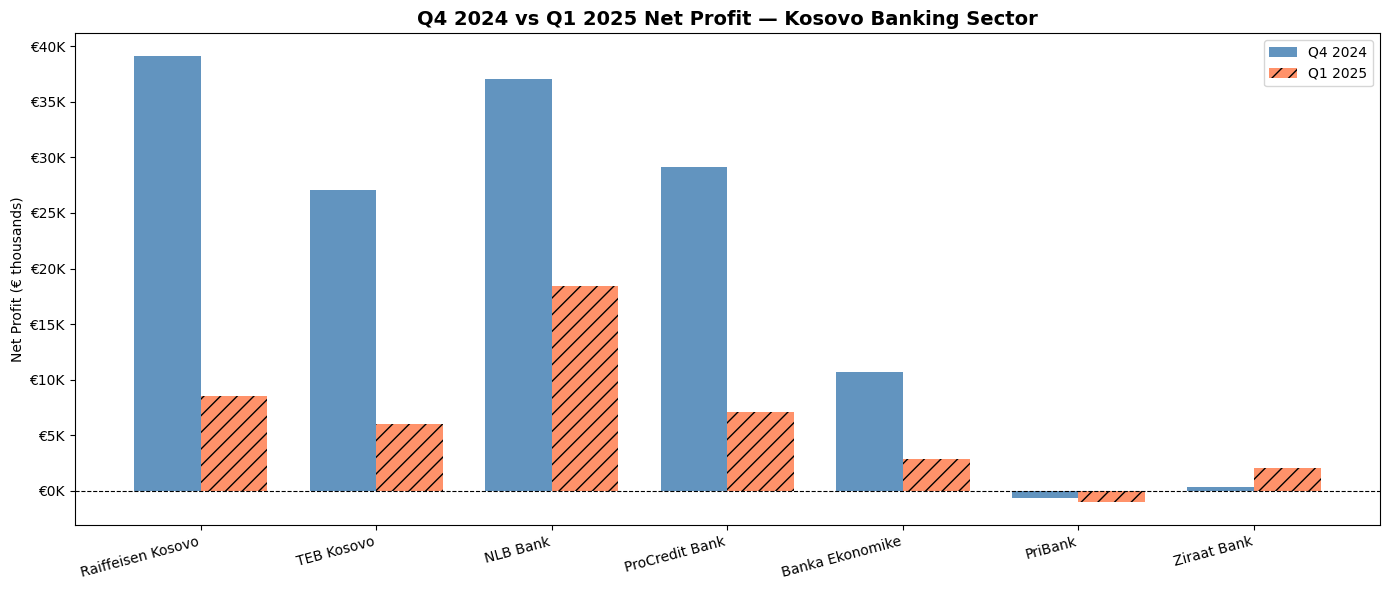

In [73]:
q4_2024 = pivot[(pivot['YEAR'] == 2024) & (pivot['QUARTER'] == 4)][['DATA_SOURCE', 16]].rename(columns={16: 'Q4 2024'})
q1_2025 = pivot[(pivot['YEAR'] == 2025) & (pivot['QUARTER'] == 1)][['DATA_SOURCE', 16]].rename(columns={16: 'Q1 2025'})

plot_data = q4_2024.merge(q1_2025, on='DATA_SOURCE')

fig, ax = plt.subplots(figsize=(14, 6))

banks = plot_data['DATA_SOURCE']
x = np.arange(len(banks))
width = 0.38

ax.bar(x - width/2, plot_data['Q4 2024'] / 1_000, width, label='Q4 2024', color='steelblue', alpha=0.85)
ax.bar(x + width/2, plot_data['Q1 2025'] / 1_000, width, label='Q1 2025', color='coral', alpha=0.85, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(banks, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Net Profit (€ thousands)')
ax.set_title('Q4 2024 vs Q1 2025 Net Profit — Kosovo Banking Sector', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'€{v:,.0f}K'))
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [74]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

latest_per_bank = pivot.groupby('BANK_ID').apply(lambda x: x.sort_values('time_idx').iloc[-1]).reset_index(drop=True)

financial_cols = [c for c in latest_per_bank.columns if isinstance(c, int)]

X_cluster = latest_per_bank[financial_cols].fillna(0)

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

print(f'Banks: {len(latest_per_bank)}')
print(f'Features used: {len(financial_cols)}')
print(latest_per_bank[['DATA_SOURCE', 'YEAR', 'QUARTER']])

Banks: 7
Features used: 43
         DATA_SOURCE    YEAR  QUARTER
0  Raiffeisen Kosovo  2025.0      4.0
1         TEB Kosovo  2025.0      4.0
2           NLB Bank  2025.0      3.0
3     ProCredit Bank  2025.0      4.0
4    Banka Ekonomike  2025.0      4.0
5            PriBank  2025.0      4.0
6        Ziraat Bank  2025.0      4.0


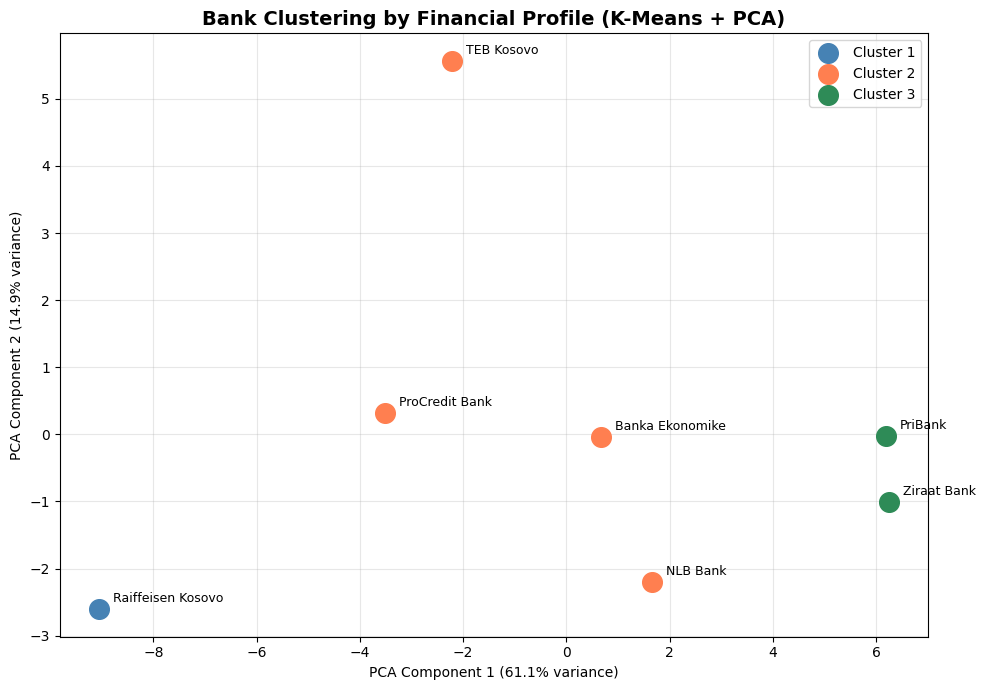


Cluster assignments:
      DATA_SOURCE  Cluster
Raiffeisen Kosovo        0
       TEB Kosovo        1
         NLB Bank        1
   ProCredit Bank        1
  Banka Ekonomike        1
          PriBank        2
      Ziraat Bank        2


In [75]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)

latest_per_bank['Cluster'] = clusters

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

latest_per_bank['PCA1'] = X_pca[:, 0]
latest_per_bank['PCA2'] = X_pca[:, 1]


colors = ['steelblue', 'coral', 'seagreen']
fig, ax = plt.subplots(figsize=(10, 7))

for cluster in range(3):
    mask = latest_per_bank['Cluster'] == cluster
    ax.scatter(
        latest_per_bank[mask]['PCA1'],
        latest_per_bank[mask]['PCA2'],
        c=colors[cluster],
        s=200,
        label=f'Cluster {cluster + 1}',
        zorder=5
    )


for _, row in latest_per_bank.iterrows():
    ax.annotate(
        row['DATA_SOURCE'],
        (row['PCA1'], row['PCA2']),
        textcoords='offset points',
        xytext=(10, 5),
        fontsize=9
    )

ax.set_title('Bank Clustering by Financial Profile (K-Means + PCA)', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nCluster assignments:')
print(latest_per_bank[['DATA_SOURCE', 'Cluster']].sort_values('Cluster').to_string(index=False))